In [1]:
import pandas as pd

rock_df = pd.read_csv("../data/clean/rock_dataset_cleaned.csv")
rock_df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit,track_name_length,artist_count,duration_min
0,4h9wh7iOZ0GGn8QVp4RAOB,OneRepublic,I Ain’t Worried (Music From The Motion Picture...,I Ain't Worried,96,148485,False,0.704,0.797,0,...,0.000745,0.0546,0.825,139.994,4,rock,1,15,1,2.474750
1,2QjOHCTQ1Jl3zawyYOpxh6,The Neighbourhood,I Love You.,Sweater Weather,93,240400,False,0.612,0.807,10,...,0.017700,0.1010,0.398,124.053,4,rock,1,15,1,4.006667
2,5XeFesFbtLpXzIVDNQP22n,Arctic Monkeys,AM,I Wanna Be Yours,92,183956,False,0.464,0.417,0,...,0.022000,0.0974,0.479,67.528,4,rock,1,16,1,3.065933
3,75FEaRjZTKLhTrFGsfMUXR,Kate Bush,Hounds Of Love,Running Up That Hill (A Deal With God),90,298933,False,0.629,0.547,10,...,0.003140,0.0604,0.197,108.375,4,rock,1,38,1,4.982217
4,7DbdUf8aHSYoliSjO6LZv6,Beach Weather,Chit Chat,"Sex, Drugs, Etc.",90,196784,False,0.572,0.839,4,...,0.009760,0.5220,0.465,143.969,4,rock,1,16,1,3.279733


In [2]:
features = [
    "danceability",
    "energy",
    "acousticness",
    "instrumentalness",
    "valence",
    "tempo",
    "loudness"
]

X = rock_df[features]
y = rock_df["is_hit"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.99      0.84       851
           1       0.17      0.00      0.01       325

    accuracy                           0.72      1176
   macro avg       0.44      0.50      0.42      1176
weighted avg       0.57      0.72      0.61      1176



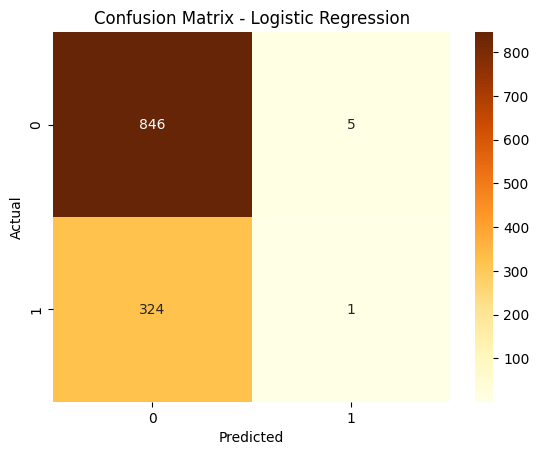

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.58      0.67       851
           1       0.35      0.60      0.45       325

    accuracy                           0.59      1176
   macro avg       0.57      0.59      0.56      1176
weighted avg       0.67      0.59      0.61      1176



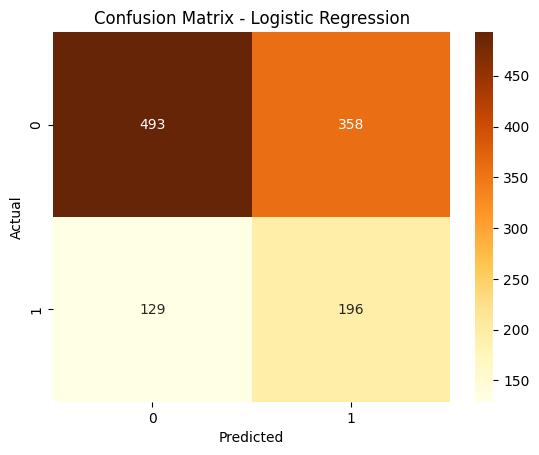

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Effect of Class Imbalance

The initial logistic regression model achieved higher accuracy (0.71), but performed very poorly in identifying hit songs, with a recall of only 0.06 for the hit class. This indicates that the model largely predicts songs as non-hits due to class imbalance.

To address this, a class-weighted logistic regression model was used. This improved the recall for hit songs significantly (to approximately 0.60), meaning the model became much better at detecting hits.

However, this improvement came at the cost of overall accuracy (which dropped to 0.59) and a large increase in false positives. The model now frequently misclassifies non-hit songs as hits.

This tradeoff suggests that while audio features contain some predictive signal, they do not provide a strong or clean separation between hit and non-hit songs.

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.73      0.96      0.83       851
           1       0.37      0.06      0.11       325

    accuracy                           0.71      1176
   macro avg       0.55      0.51      0.47      1176
weighted avg       0.63      0.71      0.63      1176



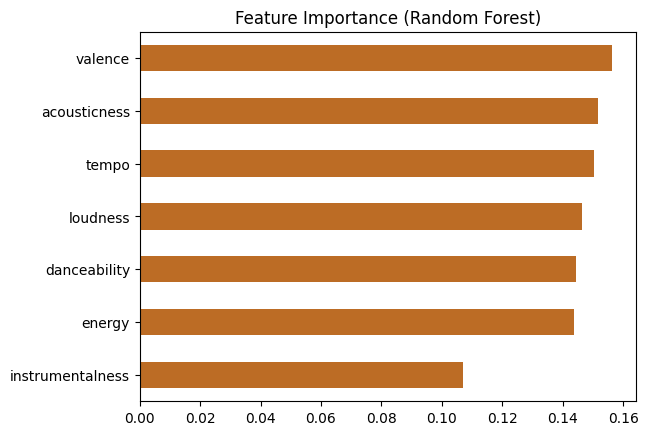

In [9]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values().plot(kind="barh", color="#BC6C25")
plt.title("Feature Importance (Random Forest)")
plt.show()